# Load Datasets

In [53]:
import pandas as pd
import numpy as np 

# ─────────────────────────────────────────────
# Dataset paths
# ─────────────────────────────────────────────
historical_data   = "raw_data.csv"

hjm_data = r"last run 18-5/18-5 hjm-pca 1 start curve.csv"
current_diffusion = r"last run 18-5/18-5 diffusion 1 start curve.csv"
VAE_data = r"last run 18-5/18-5 VAE 1 start curve right format.csv"


# All generated scenario files are capped at 200 scenarios
N_SCENARIOS = 200

def load_scenarios(path, n_scen=N_SCENARIOS):
    """
    Load a generated-scenario csv (Scenario_ID, Month, Y_1M … Y_30Y)
    and keep the first `n_scen` scenarios.
    """
    df = pd.read_csv(path)
    keep_ids = df["Scenario_ID"].unique()[:n_scen]
    return df[df["Scenario_ID"].isin(keep_ids)].reset_index(drop=True)

# Registry of every generative model — used by the comparison loops further down
MODELS = {
    "Diffusion": current_diffusion,
    "HJM-PCA":   hjm_data,
    "VAE":       VAE_data,
}


preprocess historical data

In [54]:
# ─────────────────────────────────────────────
# Historical-data preparation
# ─────────────────────────────────────────────
# The historical CSV contains daily observations of the yield curve plus three
# macro columns (FedFunds, CPI_Level, Real_GDP). For the evaluation we need:
#   1. daily → monthly data (end-of-month value)
#   2. drop the three macro columns so only the yield curve remains
#   3. build rolling windows of 60 timesteps, shifting by 1 month each time
#      (comparable to the 60-month generated scenarios)
#
# `prepare_historical_data` is the single entry point used everywhere in this
# notebook whenever we need the monthly historical data or rolling windows.

HIST_YIELD_COLS = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y", "Yield_2Y",
    "Yield_3Y", "Yield_5Y", "Yield_7Y", "Yield_10Y", "Yield_20Y", "Yield_30Y",
]
MACRO_COLS   = ["FedFunds", "CPI_Level", "Real_GDP"]
WINDOW_SIZE  = 60     # rolling window length (months) — matches scenario horizon
WINDOW_STEP  = 1      # shift by 1 month (rolling, not tumbling)


def prepare_historical_data(path=historical_data,
                            window=WINDOW_SIZE,
                            step=WINDOW_STEP):
    """
    Transform the raw historical CSV into the objects used by every
    evaluation section.

    Steps
    -----
    1. Parse DATE, sort, set as index.
    2. Resample daily → monthly (end-of-month) keeping the last observation
       of every month.
    3. Drop the three macro columns (FedFunds, CPI_Level, Real_GDP); only
       the 11 yield-curve columns remain.
    4. Build rolling windows of `window` months shifted by `step` months.

    Returns
    -------
    hist_monthly : pd.DataFrame
        (n_months, 11) — monthly yield curve, indexed by month-end DATE.
    hist_windows : np.ndarray
        (n_windows, window, 11) — rolling windows of the monthly data.
    """
    # 1. load
    df = pd.read_csv(path, parse_dates=["DATE"])
    df = df.set_index("DATE").sort_index()

    # 2. daily → monthly (end-of-month: last observation per month)
    monthly = df.resample("ME").last()

    # 3. drop the three macro columns — keep only the yield curve
    monthly = monthly.drop(columns=MACRO_COLS, errors="ignore")
    monthly = monthly[HIST_YIELD_COLS].dropna()

    # 4. rolling windows of `window` months, shift = `step`
    arr = monthly.values                 # (n_months, 11)
    n   = len(arr)
    if n < window:
        raise ValueError(f"Only {n} monthly observations; need at least {window}.")
    windows = np.stack([arr[s:s + window]
                        for s in range(0, n - window + 1, step)])
    return monthly, windows


# Run once and expose the results as module-level globals so every downstream
# cell can reuse them without re-loading or re-resampling the raw csv.
hist_monthly, hist_windows = prepare_historical_data()

print(f"Historical monthly observations : {hist_monthly.shape[0]}  "
      f"({hist_monthly.index[0].strftime('%Y-%m')} → "
      f"{hist_monthly.index[-1].strftime('%Y-%m')})")
print(f"Columns retained                : {list(hist_monthly.columns)}")
print(f"Rolling windows (60m, step 1)   : {hist_windows.shape}  "
      f"(n_windows, window, n_maturities)")


Historical monthly observations : 290  (2002-01 → 2026-02)
Columns retained                : ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y', 'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']
Rolling windows (60m, step 1)   : (231, 60, 11)  (n_windows, window, n_maturities)


# Volatility

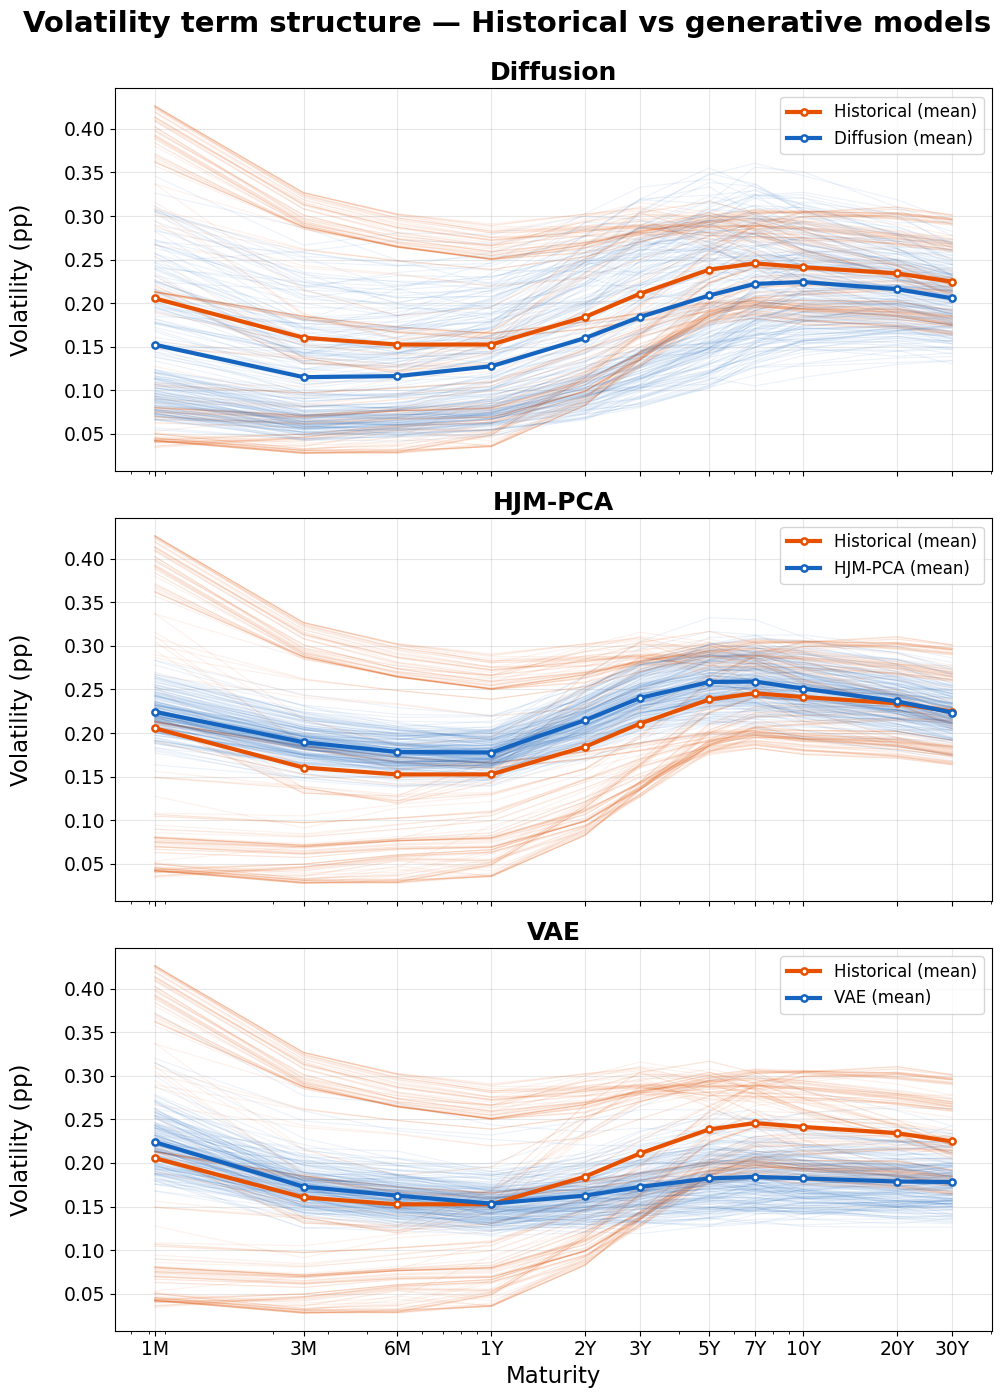

In [82]:
# ── Global scaling variables ─────────────────────────────────────────────────
FS = 1.5

TITLE_SIZE     = 12 * FS
LABEL_SIZE     = 11 * FS
TICK_SIZE      = 9 * FS
LEGEND_SIZE    = 8 * FS
SUPTITLE_SIZE  = 14 * FS

MEAN_LW        = 3
PATH_LW        = 0.8

MEAN_MARKER    = 3 * FS

FIG_W          = 10
FIG_H          = 14


# ─────────────────────────────────────────────
# Plot: vertical layout
# ─────────────────────────────────────────────

fig, axes = plt.subplots(
    3,
    1,
    figsize=(FIG_W, FIG_H),
    sharex=True,
    sharey=True
)

fig.suptitle(
    "Volatility term structure — Historical vs generative models",
    fontsize=SUPTITLE_SIZE,
    fontweight="bold",
    y=0.995
)

HIST_C = "#E65100"
SIM_C  = "#1565C0"

for i, (ax, (name, curves)) in enumerate(
    zip(axes, sim_vol_curves.items())
):

    # Historical windows
    for v in hist_vol_curves:

        ax.plot(
            MATURITY_YEARS,
            v,
            color=HIST_C,
            alpha=0.08,
            lw=PATH_LW
        )

    # Generated scenarios
    for v in curves:

        ax.plot(
            MATURITY_YEARS,
            v,
            color=SIM_C,
            alpha=0.08,
            lw=PATH_LW
        )

    # Mean curves
    ax.plot(
        MATURITY_YEARS,
        hist_vol_mean,
        color=HIST_C,
        lw=MEAN_LW,
        marker="o",
        markersize=MEAN_MARKER,
        markerfacecolor="white",
        markeredgewidth=1.8,
        label="Historical (mean)"
    )

    ax.plot(
        MATURITY_YEARS,
        curves.mean(axis=0),
        color=SIM_C,
        lw=MEAN_LW,
        marker="o",
        markersize=MEAN_MARKER,
        markerfacecolor="white",
        markeredgewidth=1.8,
        label=f"{name} (mean)"
    )

    ax.set_xscale("log")

    ax.set_xticks(MATURITY_YEARS)

    ax.set_xticklabels(
        MATURITY_LABELS,
        fontsize=TICK_SIZE
    )

    ax.set_title(
        name,
        fontsize=TITLE_SIZE,
        fontweight="bold"
    )

    # Only bottom plot gets x-label
    if i == len(axes) - 1:

        ax.set_xlabel(
            "Maturity",
            fontsize=LABEL_SIZE
        )

    else:

        ax.tick_params(labelbottom=False)

    ax.set_ylabel(
        "Volatility (pp)",
        fontsize=LABEL_SIZE,
        labelpad=22
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

    ax.grid(alpha=0.3)

    ax.legend(
        loc="upper right",
        fontsize=LEGEND_SIZE
    )

plt.tight_layout()

plt.show()

In [56]:
# ─────────────────────────────────────────────
# Mean curve error  E^mean = (1/M) Σ_m (σ̄_m − σ_m^hist)²
# σ̄_m   = mean simulated volatility across all scenarios at maturity m
# σ_m^hist = historical mean volatility at maturity m
# ─────────────────────────────────────────────

rows = []
for name, curves in sim_vol_curves.items():
    sigma_bar  = curves.mean(axis=0)          # (11,) — mean across scenarios
    E_mean     = ((sigma_bar - hist_vol_mean) ** 2).mean()
    rows.append({"Model": name, "E_mean": E_mean})

E_mean_df = pd.DataFrame(rows).set_index("Model").sort_values("E_mean")

print("Mean curve error (×10⁻³) — lower is better")
print("=" * 42)
print((E_mean_df * 1000).round(5).to_string())

Mean curve error (×10⁻³) — lower is better
            E_mean
Model             
HJM-PCA    0.45237
Diffusion  0.95464
VAE        1.65870


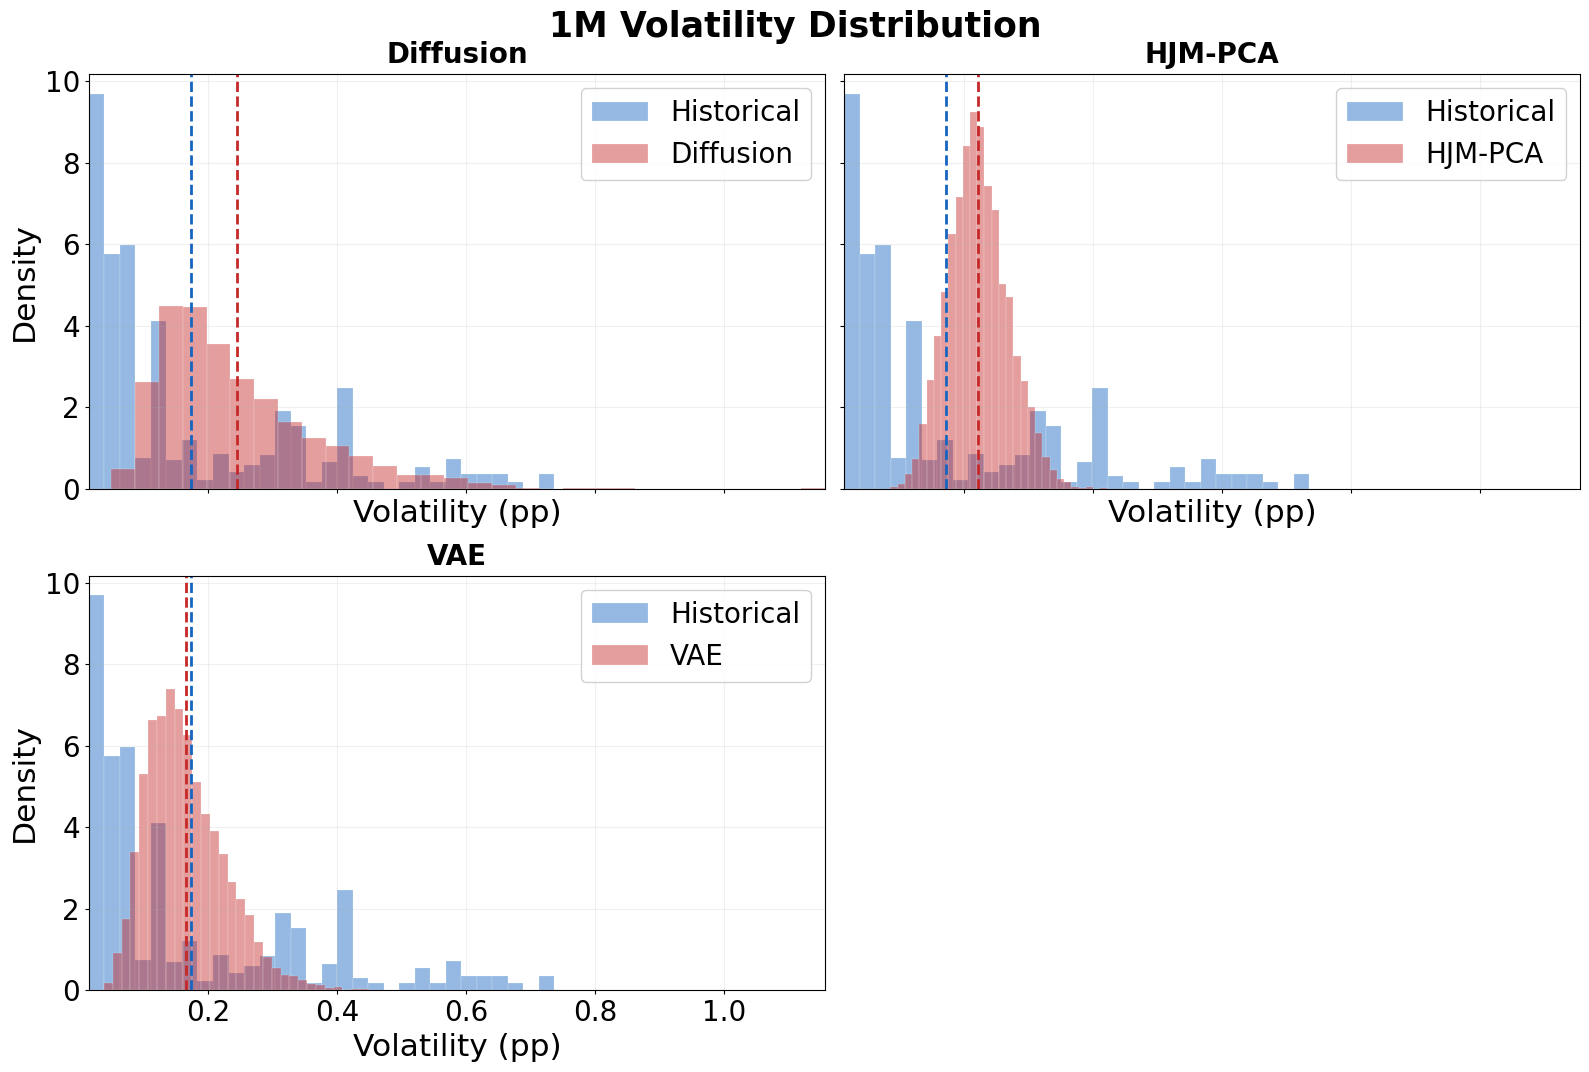

In [108]:
# ── Global font scaling ──────────────────────────────────────────────────────
FS = 2.5

TITLE_SIZE     = 8 * FS
LABEL_SIZE     = 9 * FS
TICK_SIZE      = 8 * FS
LEGEND_SIZE    = 8 * FS
SUPTITLE_SIZE  = 10 * FS

FIG_W = 16
FIG_H = 11


# ── Standard subplot layout (2x2) ───────────────────────────────────────────
fig, axes = plt.subplots(
    2,
    2,
    figsize=(FIG_W, FIG_H),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

fig.suptitle(
    "1M Volatility Distribution",
    fontsize=SUPTITLE_SIZE,
    fontweight="bold",
    y=0.97
)


# ── Plots ────────────────────────────────────────────────────────────────────
for i, (ax, (name, model_vol_1m_1y)) in enumerate(
    zip(axes, model_vols.items())
):

    # Histograms
    ax.hist(
        hist_vol_1m_1y,
        bins=30,
        density=True,
        alpha=0.45,
        color="#1565C0",
        edgecolor="white",
        lw=0.3,
        label="Historical"
    )

    ax.hist(
        model_vol_1m_1y,
        bins=30,
        density=True,
        alpha=0.45,
        color="#C62828",
        edgecolor="white",
        lw=0.3,
        label=name
    )

    # Mean lines
    ax.axvline(
        hist_vol_1m_1y.mean(),
        color="#1565C0",
        lw=2,
        ls="--"
    )

    ax.axvline(
        model_vol_1m_1y.mean(),
        color="#C62828",
        lw=2,
        ls="--"
    )

    ax.set_title(
        name,
        fontsize=TITLE_SIZE,
        fontweight="bold",
        pad=8
    )

    ax.set_xlabel(
    "Volatility (pp)",
    fontsize=LABEL_SIZE
    )

    # Left column only
    if i % 2 == 0:

        ax.set_ylabel(
            "Density",
            fontsize=LABEL_SIZE
        )

    else:

        ax.tick_params(labelleft=False)

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE,
        length=3
    )

    ax.set_xlim(x_min, x_max)

    ax.grid(alpha=0.18)

    ax.legend(
        fontsize=LEGEND_SIZE,
        framealpha=0.9,
        loc="upper right"
    )

# Remove unused 4th subplot
axes[-1].set_visible(False)

plt.tight_layout()

plt.show()

In [58]:
# ─────────────────────────────────────────────
# Volatility distribution — short (1M) vs long (avg 10Y/20Y/30Y) maturities
# ─────────────────────────────────────────────
# Using 1-year and 5-year rolling windows on monthly yield changes we obtain,
# for each model and for the historical data, a distribution of volatility
# estimates. The distributions are then compared along:
#   • mean and spread (P95 - P5)
#   • Wasserstein distance (overall shape match)
#   • EVF Error   = |p_sim - p_hist| where p is the proportion of obs. above
#                  the historical 95th percentile (extreme volatility freq.)
#   • skewness and kurtosis (descriptive, tail shape)
from scipy.stats import wasserstein_distance, skew, kurtosis

SHORT_HIST = "Yield_1M"
LONG_HIST  = ["Yield_10Y", "Yield_20Y", "Yield_30Y"]
SHORT_SIM  = "Y_1M"
LONG_SIM   = ["Y_10Y", "Y_20Y", "Y_30Y"]


def rolling_vol(series, window):
    """Rolling-window std of first differences; falls back to full-series std
    when the series is too short for the requested window."""
    diffs = series.diff().dropna()
    if window <= len(diffs):
        return diffs.rolling(window).std().dropna().values
    return np.array([diffs.std()])


def hist_vol_dist(cols, window):
    series = hist_monthly[cols].mean(axis=1) if isinstance(cols, list) else hist_monthly[cols]
    return rolling_vol(series, window)


def sim_vol_dist(path, cols, window):
    df = load_scenarios(path)
    out = []
    for _, g in df.groupby("Scenario_ID"):
        g = g.sort_values("Month")
        series = g[cols].mean(axis=1) if isinstance(cols, list) else g[cols]
        out.append(rolling_vol(series, window))
    return np.concatenate(out)


# ─────────────────────────────────────────────
# Compute distributions for each (window, maturity-segment, model)
# ─────────────────────────────────────────────
dist_rows = []
for window_label, window in [("1Y", 12), ("5Y", 60)]:
    for seg_label, hcols, scols in [
        ("Short (1M)",                SHORT_HIST, SHORT_SIM),
        ("Long (avg 10Y/20Y/30Y)",    LONG_HIST,  LONG_SIM),
    ]:
        h = hist_vol_dist(hcols, window)
        h_p95   = np.percentile(h, 95)
        h_mean  = h.mean()
        h_spread = np.percentile(h, 95) - np.percentile(h, 5)
        p_hist  = (h > h_p95).mean()

        # historical reference row
        dist_rows.append({
            "Window":     window_label,
            "Maturity":   seg_label,
            "Model":      "Historical",
            "Mean":       h_mean,
            "Spread":     h_spread,
            "Wasserstein": 0.0,
            "EVF Error":  0.0,
            "Skew":       skew(h),
            "Kurt":       kurtosis(h),
        })

        for name, path in MODELS.items():
            s = sim_vol_dist(path, scols, window)
            p_sim = (s > h_p95).mean()
            dist_rows.append({
                "Window":     window_label,
                "Maturity":   seg_label,
                "Model":      name,
                "Mean":       s.mean(),
                "Spread":     np.percentile(s, 95) - np.percentile(s, 5),
                "Wasserstein": wasserstein_distance(h, s),
                "EVF Error":  abs(p_sim - p_hist),
                "Skew":       skew(s),
                "Kurt":       kurtosis(s),
            })

dist_df = pd.DataFrame(dist_rows)

# Pretty print grouped by window + maturity segment
print("Volatility distribution analysis — short vs long maturities")
print("=" * 90)
for (window, seg), sub in dist_df.groupby(["Window", "Maturity"], sort=False):
    print(f"\n── {window} rolling window · {seg} ──")
    print(sub.drop(columns=["Window", "Maturity"])
            .set_index("Model")
            .round(4)
            .to_string())


Volatility distribution analysis — short vs long maturities

── 1Y rolling window · Short (1M) ──
              Mean  Spread  Wasserstein  EVF Error    Skew    Kurt
Model                                                             
Historical  0.1716  0.5210       0.0000     0.0000  1.3720  1.1717
Diffusion   0.2450  0.3859       0.0805     0.0184  1.4762  3.5379
HJM-PCA     0.2228  0.1536       0.1205     0.0504  0.2552 -0.0304
VAE         0.1652  0.1916       0.0835     0.0504  0.7920  0.6861

── 1Y rolling window · Long (avg 10Y/20Y/30Y) ──
              Mean  Spread  Wasserstein  EVF Error    Skew    Kurt
Model                                                             
Historical  0.2322  0.2217       0.0000     0.0000  1.2856  1.8656
Diffusion   0.2311  0.2407       0.0085     0.0042  0.9227  1.4043
HJM-PCA     0.2323  0.1672       0.0199     0.0412  0.2682  0.1437
VAE         0.1601  0.1496       0.0722     0.0496  0.6856  0.6925

── 5Y rolling window · Short (1M) ──
          